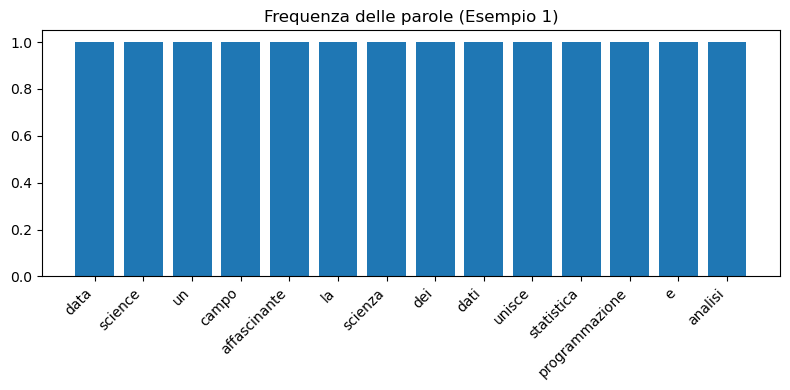

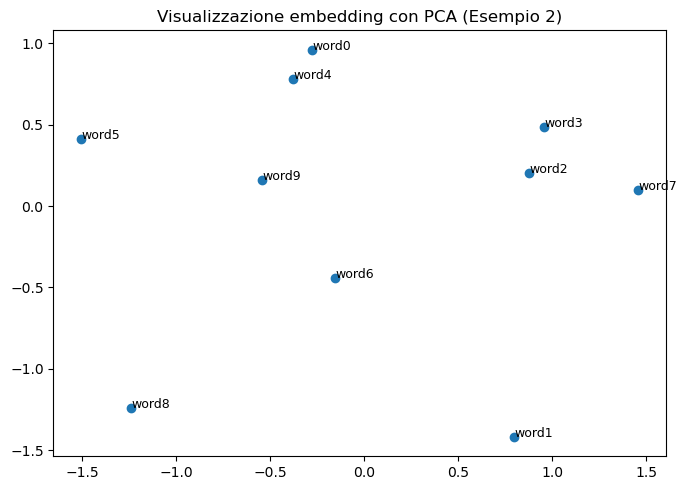

/var/folders/1n/mz62ctz90v99plrlmklqf_1c0000gn/T/ipykernel_9271/222642963.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=cats)


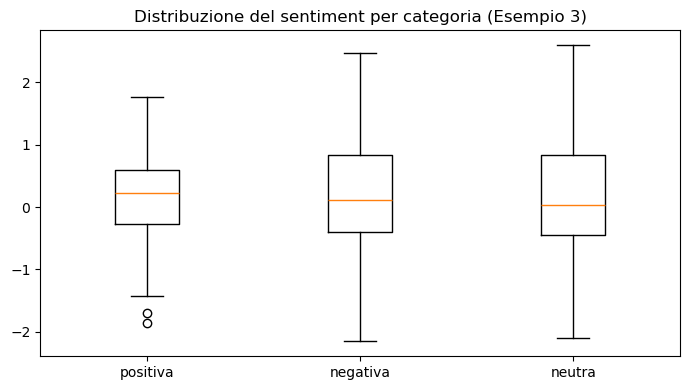

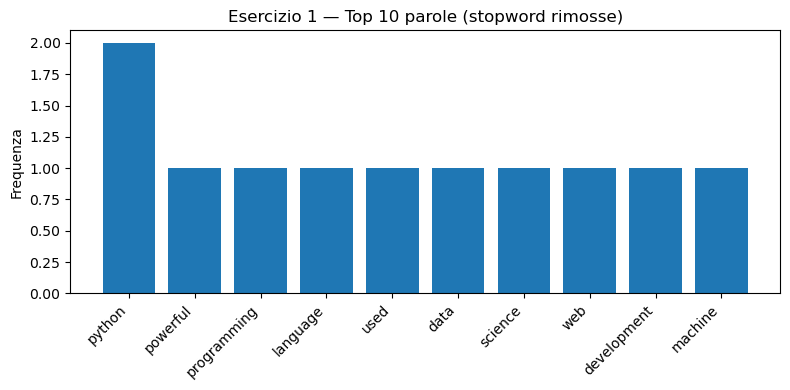

Legami più forti (w1 -> w2): [('python', 'powerful', 1), ('python', 'used', 1), ('powerful', 'programming', 1), ('programming', 'language', 1), ('language', 'python', 1), ('used', 'data', 1), ('data', 'science', 1), ('science', 'web', 1), ('web', 'development', 1), ('development', 'machine', 1)]


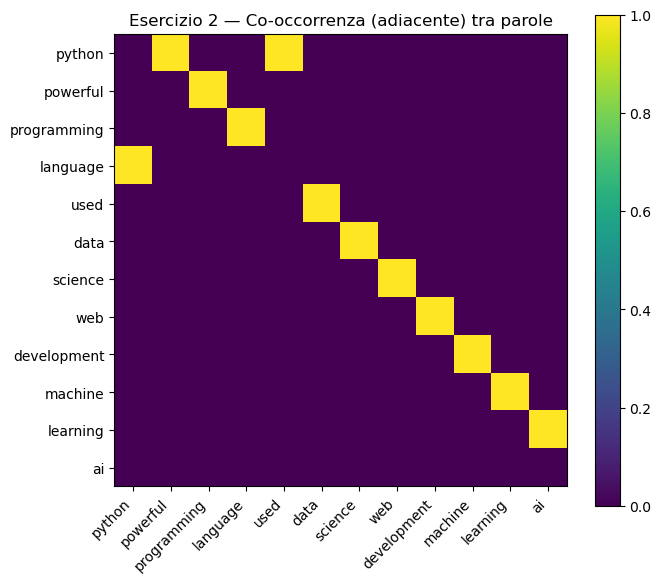

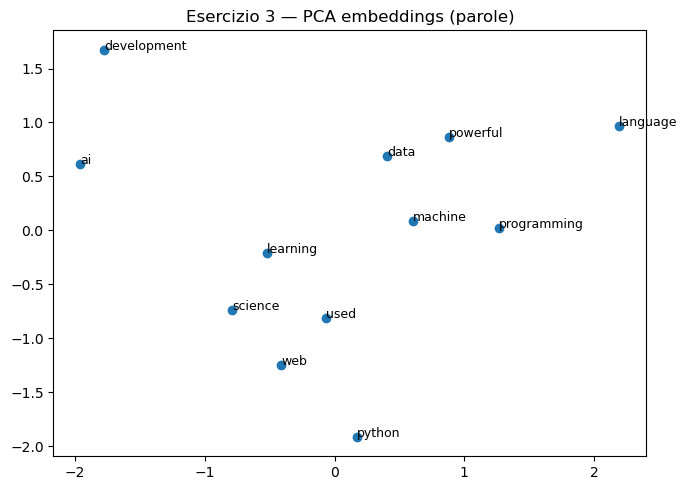

/var/folders/1n/mz62ctz90v99plrlmklqf_1c0000gn/T/ipykernel_9271/222642963.py:241: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=cats)


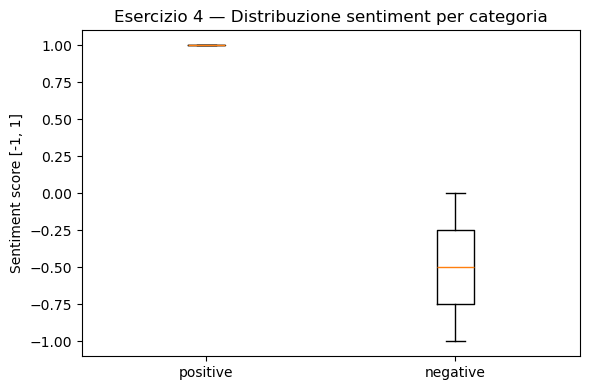

Topic 1: ['machine', 'statistics', 'data', 'learning', 'validation', 'training', 'features', 'models']


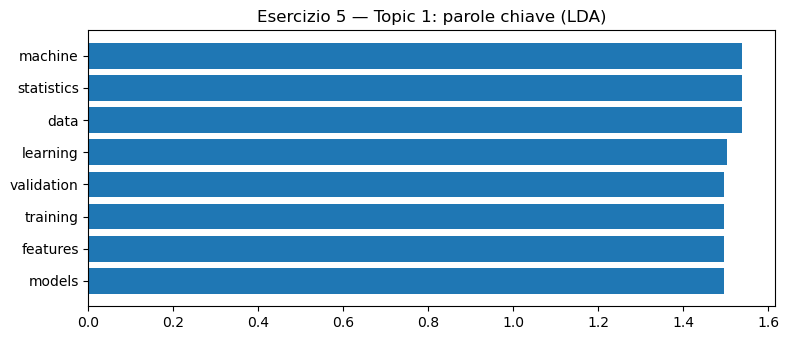

Topic 2: ['learning', 'ai', 'python', 'networks', 'transformers', 'neural', 'deep', 'embeddings']


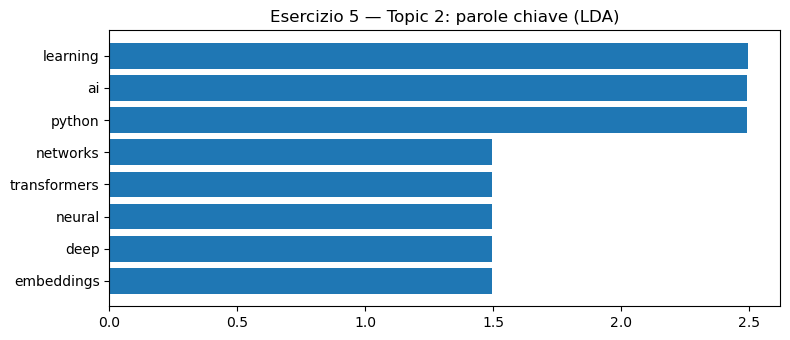

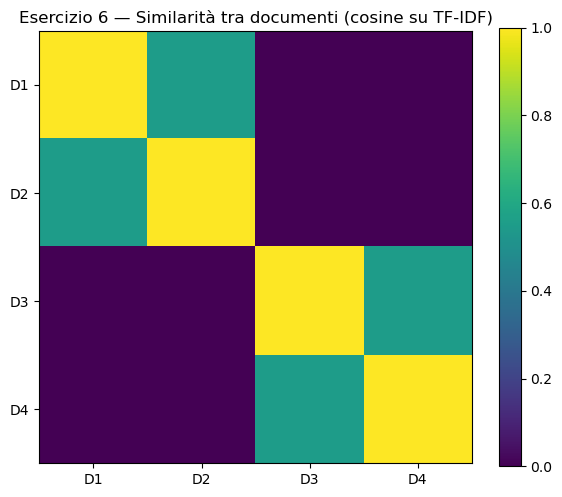

In [1]:
"""
2_412 — Visualizzazioni per dati testuali e NLP
Esempi + Esercizi rielaborati (docstring + commenti) a partire dal codice fornito.

Requisiti:
    pip install numpy pandas matplotlib scikit-learn

Nota:
- Tokenizzazione/stopword qui sono "didattiche": per produzione useresti spaCy/Stanza,
  e stopword più complete (o NLTK, se vuoi).
"""

from __future__ import annotations

import re
from collections import Counter
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity


# -------------------------
# Stopword (mini set, EN)
# -------------------------
EN_STOPWORDS_MINI = {
    "a","an","the","and","or","but","if","then","else","for","to","of","in","on","at","by","with","as",
    "is","are","was","were","be","been","being","it","this","that","these","those","i","you","he","she","we","they",
    "me","him","her","us","them","my","your","his","its","our","their",
    "not","no","yes","very","so","too","can","could","should","would","will","just",
}


def tokenize_simple(text: str) -> List[str]:
    """
    Tokenizzazione semplice e robusta per esempi:
    - lowercase
    - tiene solo lettere e apostrofi
    - split su spazi

    Perché: evita che "science," e "science." diventino token diversi.
    """
    text = text.lower()
    text = re.sub(r"[^a-z' ]+", " ", text)
    tokens = [t.strip("'") for t in text.split() if t.strip("'")]
    return tokens


def remove_stopwords(tokens: List[str], stopwords: set[str]) -> List[str]:
    """Rimuove stopword e token troppo corti (<=1)."""
    return [t for t in tokens if t not in stopwords and len(t) > 1]


def build_cooccurrence_adjacent(tokens: List[str], vocab: List[str]) -> np.ndarray:
    """
    Matrice di co-occorrenza su bigrammi adiacenti:
    M[i, j] = quante volte vocab[i] è seguito da vocab[j].

    Nota: è direzionale. Se vuoi una versione simmetrica:
        M_sym = M + M.T
    """
    idx = {w: i for i, w in enumerate(vocab)}
    M = np.zeros((len(vocab), len(vocab)), dtype=int)

    for w1, w2 in zip(tokens[:-1], tokens[1:]):
        if w1 in idx and w2 in idx:
            M[idx[w1], idx[w2]] += 1

    return M


def strongest_links(M: np.ndarray, vocab: List[str], top_k: int = 10) -> List[Tuple[str, str, int]]:
    """Estrae le coppie più forti (w1 -> w2) dalla matrice di co-occorrenza."""
    links = []
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if i != j and M[i, j] > 0:
                links.append((vocab[i], vocab[j], int(M[i, j])))
    links.sort(key=lambda x: x[2], reverse=True)
    return links[:top_k]


# Lessico sentiment (didattico)
POS_WORDS = {"love","great","excellent","good","amazing","wonderful","best","awesome","fantastic","happy","perfect","nice"}
NEG_WORDS = {"terrible","bad","awful","hate","worst","annoying","poor","horrible","waste","boring","disappointing"}


def lexicon_sentiment_score(text: str) -> float:
    """
    Sentiment score minimale:
    score = (pos - neg) / max(1, pos+neg)  -> range [-1, 1]

    È un "giocattolo" utile per fare grafici e capire pipeline,
    non un modello serio per produzione.
    """
    tokens = tokenize_simple(text)
    pos = sum(t in POS_WORDS for t in tokens)
    neg = sum(t in NEG_WORDS for t in tokens)
    denom = max(1, pos + neg)
    return (pos - neg) / denom


def main() -> None:
    # ======================
    # ESEMPIO 1 — Frequenze
    # ======================
    testo = "Data Science è un campo affascinante. La scienza dei dati unisce statistica, programmazione e analisi."
    tokens = tokenize_simple(testo)
    freq = Counter(tokens)

    # Niente "tips come dummy": faccio un DataFrame reale
    df_freq = pd.DataFrame({"parola": list(freq.keys()), "conteggio": list(freq.values())})
    df_freq = df_freq.sort_values("conteggio", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(df_freq["parola"], df_freq["conteggio"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Frequenza delle parole (Esempio 1)")
    plt.tight_layout()
    plt.show()

    # ============================
    # ESEMPIO 2 — Embedding + PCA
    # ============================
    np.random.seed(0)
    embeddings = np.random.rand(10, 50)

    pca = PCA(n_components=2)
    ridotto = pca.fit_transform(embeddings)

    df = pd.DataFrame(ridotto, columns=["PC1", "PC2"])
    df["parola"] = [f"word{i}" for i in range(10)]

    plt.figure(figsize=(7, 5))
    plt.scatter(df["PC1"], df["PC2"])
    for _, r in df.iterrows():
        plt.text(r["PC1"], r["PC2"], r["parola"], fontsize=9)
    plt.title("Visualizzazione embedding con PCA (Esempio 2)")
    plt.tight_layout()
    plt.show()

    # =========================================
    # ESEMPIO 3 — Distribuzione sentiment (box)
    # =========================================
    np.random.seed(1)
    df_sentiment = pd.DataFrame({
        "categoria": np.random.choice(["positiva", "negativa", "neutra"], 200),
        "valore": np.random.normal(0, 1, 200)
    })

    cats = ["positiva", "negativa", "neutra"]
    data_box = [df_sentiment.loc[df_sentiment["categoria"] == c, "valore"].values for c in cats]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data_box, labels=cats)
    plt.title("Distribuzione del sentiment per categoria (Esempio 3)")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # ESERCIZIO 1 — Frequenze (stopword + sort)
    # ==========================================
    text = """
    Python is a powerful programming language. Python is used in data science, web development, machine learning, and AI.
    It is versatile, easy to learn, and widely adopted by professionals.
    """
    tokens = tokenize_simple(text)
    tokens_clean = remove_stopwords(tokens, EN_STOPWORDS_MINI)

    freq = Counter(tokens_clean)
    most_common = freq.most_common(10)

    df_top = pd.DataFrame(most_common, columns=["word", "count"]).sort_values("count", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(df_top["word"], df_top["count"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Esercizio 1 — Top 10 parole (stopword rimosse)")
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()

    # ===================================
    # ESERCIZIO 2 — Heatmap co-occorrenza
    # ===================================
    # Per avere una heatmap leggibile: top-K parole
    vocab = [w for w, _ in freq.most_common(12)]
    M = build_cooccurrence_adjacent(tokens_clean, vocab)

    print("Legami più forti (w1 -> w2):", strongest_links(M, vocab, top_k=10))

    plt.figure(figsize=(7, 6))
    plt.imshow(M)
    plt.colorbar()
    plt.xticks(range(len(vocab)), vocab, rotation=45, ha="right")
    plt.yticks(range(len(vocab)), vocab)
    plt.title("Esercizio 2 — Co-occorrenza (adiacente) tra parole")
    plt.tight_layout()
    plt.show()

    # =============================================
    # ESERCIZIO 3 — PCA su embedding + scatter label
    # =============================================
    rng = np.random.default_rng(42)
    embeddings_words = rng.normal(0, 1, size=(len(vocab), 8))

    pca = PCA(n_components=2, random_state=42)
    pca_result = pca.fit_transform(embeddings_words)

    df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
    df_pca["word"] = vocab

    plt.figure(figsize=(7, 5))
    plt.scatter(df_pca["PC1"], df_pca["PC2"])
    for _, r in df_pca.iterrows():
        plt.text(r["PC1"], r["PC2"], r["word"], fontsize=9)
    plt.title("Esercizio 3 — PCA embeddings (parole)")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # ESERCIZIO 4 — Sentiment recensioni + boxplot
    # ==========================================
    reviews = pd.DataFrame({
        "text": ["I love this product", "Terrible service", "Great quality", "Not worth the price", "Excellent!"],
        "category": ["positive", "negative", "positive", "negative", "positive"]
    })

    reviews["sentiment"] = reviews["text"].apply(lexicon_sentiment_score)

    cats = ["positive", "negative"]
    data_box = [reviews.loc[reviews["category"] == c, "sentiment"].values for c in cats]

    plt.figure(figsize=(6, 4))
    plt.boxplot(data_box, labels=cats)
    plt.title("Esercizio 4 — Distribuzione sentiment per categoria")
    plt.ylabel("Sentiment score [-1, 1]")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # ESERCIZIO 5 — Topic modeling (LDA sklearn)
    # ==========================================
    docs = [
        "python data science machine learning ai statistics",
        "web development python frameworks backend frontend",
        "machine learning models features training validation metrics",
        "data analysis statistics visualization pandas numpy",
        "ai deep learning neural networks embeddings transformers",
    ]

    vectorizer = CountVectorizer(stop_words=list(EN_STOPWORDS_MINI))
    X_bow = vectorizer.fit_transform(docs)

    lda = LatentDirichletAllocation(n_components=2, random_state=42, learning_method="batch")
    lda.fit(X_bow)

    feature_names = np.array(vectorizer.get_feature_names_out())

    def top_words(topic_weights: np.ndarray, top_n: int = 8) -> List[Tuple[str, float]]:
        idx = np.argsort(topic_weights)[::-1][:top_n]
        return [(feature_names[i], float(topic_weights[i])) for i in idx]

    for k in range(lda.n_components):
        tw = top_words(lda.components_[k], top_n=8)
        print(f"Topic {k+1}:", [w for w, _ in tw])

        words = [w for w, _ in tw][::-1]
        weights = [v for _, v in tw][::-1]

        plt.figure(figsize=(8, 3.5))
        plt.barh(words, weights)
        plt.title(f"Esercizio 5 — Topic {k+1}: parole chiave (LDA)")
        plt.tight_layout()
        plt.show()

    # ==========================================
    # ESERCIZIO 6 — Similarità documenti (TF-IDF)
    # ==========================================
    docs_sim = [
        "I love data science",
        "Data science is great",
        "I hate spam emails",
        "Spam emails are annoying"
    ]
    labels = [f"D{i+1}" for i in range(len(docs_sim))]

    tfidf = TfidfVectorizer(stop_words=list(EN_STOPWORDS_MINI))
    X = tfidf.fit_transform(docs_sim)
    sim = cosine_similarity(X)

    plt.figure(figsize=(6, 5))
    plt.imshow(sim)
    plt.colorbar()
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.title("Esercizio 6 — Similarità tra documenti (cosine su TF-IDF)")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

/var/folders/1n/mz62ctz90v99plrlmklqf_1c0000gn/T/ipykernel_9271/1504215530.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freq, x="parola", y="conteggio", palette="crest")


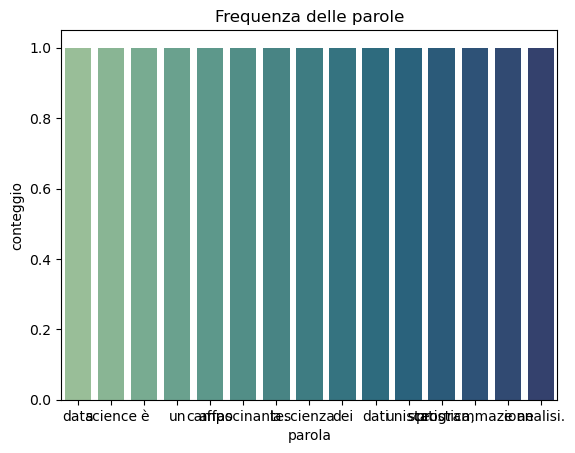

In [2]:
# #Esempio 1

import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

testo = "Data Science è un campo affascinante. La scienza dei dati unisce statistica, programmazione e analisi."
parole = [p.lower() for p in testo.split()]
frequenze = Counter(parole)
df_freq = sns.load_dataset("tips").iloc[:len(frequenze)]  # dummy dataset structure
df_freq["parola"] = list(frequenze.keys())
df_freq["conteggio"] = list(frequenze.values())

sns.barplot(data=df_freq, x="parola", y="conteggio", palette="crest")
plt.title("Frequenza delle parole")
plt.show()